# Trabajo Grupal: Predicción de Temperatura mediante Modelos de Regresión

**Asignatura:** Fundamentos del Machine Learning 
**Período:** 2025

---

## Información del Equipo

| N° | Nombre Completo |
|:---:|:----------------|
| 1 | |
| 2 | |
| 3 | |
| 4 | |
| 5 | |

---

# 1. Introducción y Lineamientos Generales

## 1.1 Objetivo del Trabajo

El objetivo de este trabajo es desarrollar un modelo de regresión para **predecir la temperatura** de una ciudad europea, utilizando datos climáticos históricos. A través de este ejercicio, aplicarán competencias de análisis exploratorio de datos, preprocesamiento, selección de variables y evaluación de modelos de aprendizaje automático.

## 1.2 Prerrequisitos

Antes de abordar esta actividad, es fundamental haber comprendido los contenidos de la unidad sobre algoritmos de aprendizaje supervisado, particularmente:
- Regresión lineal y sus variantes (Ridge, Lasso, ElasticNet)
- Árboles de decisión para regresión
- Métricas de evaluación de modelos de regresión
- Técnicas de preprocesamiento de datos

## 1.3 Formato de Entrega

> **Importante:** Este cuaderno Jupyter está diseñado para contener tanto el **código** como el **informe escrito** de manera integrada. **No es necesario entregar un documento PDF adicional.** Todas las justificaciones, análisis e interpretaciones deben escribirse directamente en las celdas Markdown correspondientes de este cuaderno.

El formato Jupyter Notebook permite combinar:
- Celdas de código ejecutable
- Celdas de texto con formato Markdown para explicaciones y análisis
- Visualizaciones integradas
- Referencias bibliográficas

## 1.4 Trabajo Colaborativo

Este es un trabajo **grupal** que requiere la participación activa y coordinada de todos los integrantes del equipo. 

Se espera que todos los miembros contribuyan de manera significativa y documentada en el espacio habilitado en el Campus Digital para la coordinación del trabajo grupal.

## 1.5 Uso de Fuentes Académicas y Citación

Todas las decisiones técnicas y metodológicas deben estar **fundamentadas con literatura académica**. Se requiere:

- Utilizar **al menos 3 fuentes académicas** pertinentes (libros, artículos científicos, documentación técnica oficial)
- Citar correctamente en formato **APA 7ª edición**
- Incluir una sección de **Referencias Bibliográficas** al final del documento

**Ejemplo de cita en texto:**
> Según Géron (2019), la estandarización de variables es fundamental antes de aplicar algoritmos de regresión regularizados.

**Ejemplo de referencia APA:**
> Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly Media.

## 1.6 Criterios de Evaluación

Este trabajo será evaluado según la siguiente rúbrica (100 puntos totales):

| Criterio | Puntos |
|:---------|:------:|
| Análisis exploratorio y preparación de datos | 20 |
| Desarrollo y evaluación del modelo | 20 |
| Selección de variables y extracción de atributos | 15 |
| Reflexión final | 10 |
| Organización y presentación de la tarea | 10 |
| Cumplimiento de normas de plazo, forma y estructura | 10 |
| Coordinación del trabajo colaborativo | 5 |
| Redacción y ortografía | 5 |
| Uso de fuentes | 5 |
| **Total** | **100** |

---

# 2. Configuración del Entorno

## 2.1 Librerías Permitidas

A continuación se importan las librerías autorizadas para este trabajo. **No está permitido** utilizar modelos basados en ensambles (Random Forest, Gradient Boosting, etc.) ni redes neuronales profundas.

In [102]:
# Librerías para manipulación de datos
import numpy as np
import pandas as pd

# Modelos de regresión permitidos
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.tree import DecisionTreeRegressor

# Herramientas de preprocesamiento y división de datos
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

# Métricas de evaluación
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# Ignorar advertencias para mejor legibilidad
import warnings
warnings.filterwarnings('ignore')

## 2.2 Carga del Conjunto de Datos

El archivo `historia_climatica.csv` contiene registros climáticos por hora de una ciudad europea.

In [103]:
df = pd.read_csv('historia_climatica.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 96453 filas × 11 columnas


,Summary,Precip Type,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Fecha
0,Partly Cloudy,rain,9.472222,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006-04-01 00:00:00
1,Partly Cloudy,rain,9.355556,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006-04-01 01:00:00
2,Mostly Cloudy,rain,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006-04-01 02:00:00
3,Partly Cloudy,rain,8.288889,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006-04-01 03:00:00
4,Mostly Cloudy,rain,8.755556,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006-04-01 04:00:00


## 2.3 Descripción de Variables

| Variable | Descripción | Tipo |
|:---------|:------------|:-----|
| `Fecha` | Momento de la medición (fecha y hora) | Temporal |
| `summary` | Descripción general del estado del tiempo | Categórica |
| `precipType` | Tipo de precipitación (lluvia, nieve, granizo) | Categórica |
| `temperature` | **Variable objetivo** - Temperatura en °C | Numérica |
| `humidity` | Porcentaje de humedad ambiental | Numérica |
| `windSpeed` | Velocidad del viento (km/h o m/s) | Numérica |
| `windBearing` | Dirección del viento en grados (desde el norte) | Numérica |
| `visibility` | Distancia de visibilidad horizontal (km) | Numérica |
| `loudCover` | Proporción de cielo cubierto por nubes (%) | Numérica |
| `pressure` | Presión atmosférica (hPa o mbar) | Numérica |
| `dailySummary` | Resumen del estado del tiempo durante el día | Categórica |

---

# 3. Análisis Exploratorio de Datos (EDA)

En esta sección se realiza una exploración inicial del conjunto de datos para comprender su estructura, identificar problemas de calidad y preparar estrategias de preprocesamiento.

## 3.1 Inspección General del Dataset

Realice una inspección inicial que incluya:
- Tipos de datos de cada columna
- Estadísticas descriptivas de variables numéricas
- Identificación de valores únicos en variables categóricas

In [104]:
print("### Tipos de datos ###")
print(df.dtypes)

print(df.describe().T)


### Tipos de datos ###
Summary                    object
Precip Type                object
Temperature (C)           float64
Humidity                  float64
Wind Speed (km/h)         float64
Wind Bearing (degrees)    float64
Visibility (km)           float64
Loud Cover                float64
Pressure (millibars)      float64
Daily Summary              object
Fecha                      object
dtype: object
                          count         mean         std        min  \
Temperature (C)         96453.0    11.932678    9.551546 -21.822222   
Humidity                96453.0     0.734899    0.195473   0.000000   
Wind Speed (km/h)       94352.0    10.812323    6.913931   0.000000   
Wind Bearing (degrees)  96453.0   187.509232  107.383428   0.000000   
Visibility (km)         96453.0    10.347325    4.192123   0.000000   
Loud Cover              96453.0     0.000000    0.000000   0.000000   
Pressure (millibars)    96281.0  1003.231319  116.982982   0.000000   

                    

In [105]:
#FALTANTES
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\nColumna: {col}")
    print(df[col].unique())



Columna: Summary
['Partly Cloudy' 'Mostly Cloudy' 'Overcast' 'Foggy'
 'Breezy and Mostly Cloudy' 'Clear' 'Breezy and Partly Cloudy'
 'Breezy and Overcast' 'Humid and Mostly Cloudy' 'Humid and Partly Cloudy'
 'Windy and Foggy' 'Windy and Overcast' 'Breezy and Foggy'
 'Windy and Partly Cloudy' 'Breezy' 'Dry and Partly Cloudy'
 'Windy and Mostly Cloudy' 'Dangerously Windy and Partly Cloudy' 'Dry'
 'Windy' 'Humid and Overcast' 'Light Rain' 'Drizzle' 'Windy and Dry'
 'Dry and Mostly Cloudy' 'Breezy and Dry' 'Rain']

Columna: Precip Type
['rain' nan 'snow']

Columna: Daily Summary
['Partly cloudy throughout the day.' 'Mostly cloudy throughout the day.'
 'Foggy in the evening.' 'Foggy overnight and breezy in the morning.'
 'Overcast throughout the day.' 'Partly cloudy until night.'
 'Mostly cloudy until night.'
 'Foggy starting overnight continuing until morning.'
 'Foggy in the morning.' 'Partly cloudy until evening.'
 'Partly cloudy starting in the morning.'
 'Mostly cloudy starting overni

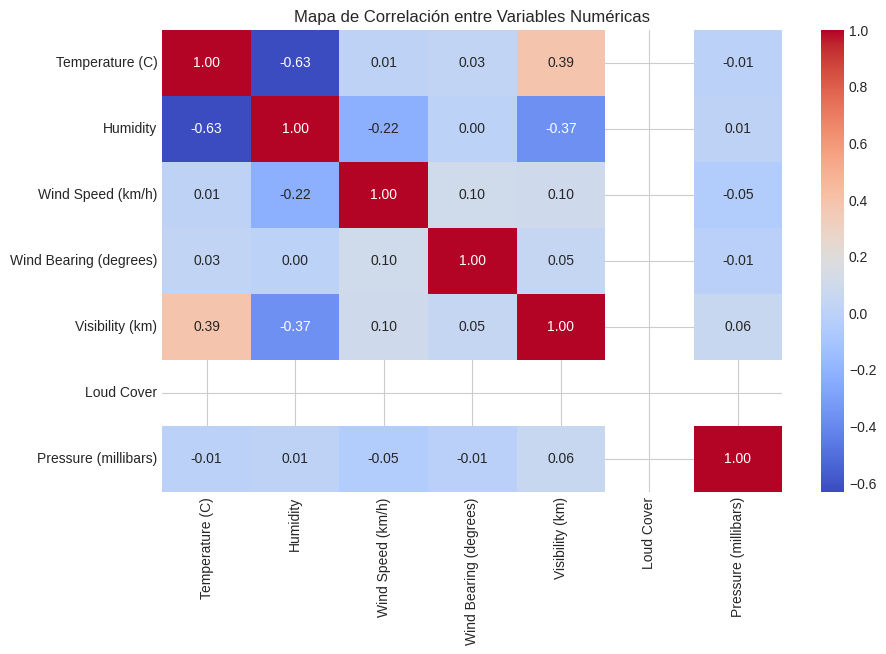

In [106]:
#Extra
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de Correlación entre Variables Numéricas")
plt.show()


**Análisis e interpretación:**

*[Escriba aquí su análisis de la inspección general del dataset. Describa los tipos de datos encontrados, rangos de valores y cualquier observación inicial relevante.]*

El dataset contiene variables numéricas, categóricas y una variable temporal.
Se observan rangos amplios en temperatura, humedad y velocidad del viento, lo que indica variabilidad climática horaria.
Las variables categóricas tienen pocas categorías repetidas, lo que facilita su codificación.
La columna Wind Speed presenta valores faltantes, por lo que será necesaria una imputación adecuada en fases posteriores.
No se observan valores extremos evidentes en presión ni visibilidad, aunque se recomienda verificar correlaciones.

## 3.2 Gestión de Datos Faltantes

Identifique las columnas con valores faltantes y desarrolle una estrategia de imputación para cada una. Justifique su decisión basándose en la naturaleza de cada variable.

**Técnicas sugeridas:**
- Imputación por media/mediana/moda
- Imputación por KNN (`KNNImputer`)
- Eliminación de filas/columnas (solo si es justificable)

In [107]:
# Su código aquí - Identificación de valores faltantes
# Identificación de valores faltantes por columna
df.isna().sum()
print(df.isna().sum())

print("/n")
#porcentaje
# Identificación de valores faltantes por columna
df.isna().sum()
print((df.isna().mean()*100).round(2))

Summary                      0
Precip Type               1472
Temperature (C)              0
Humidity                     0
Wind Speed (km/h)         2101
Wind Bearing (degrees)       0
Visibility (km)              0
Loud Cover                   0
Pressure (millibars)       172
Daily Summary                0
Fecha                        0
dtype: int64
/n
Summary                   0.00
Precip Type               1.53
Temperature (C)           0.00
Humidity                  0.00
Wind Speed (km/h)         2.18
Wind Bearing (degrees)    0.00
Visibility (km)           0.00
Loud Cover                0.00
Pressure (millibars)      0.18
Daily Summary             0.00
Fecha                     0.00
dtype: float64


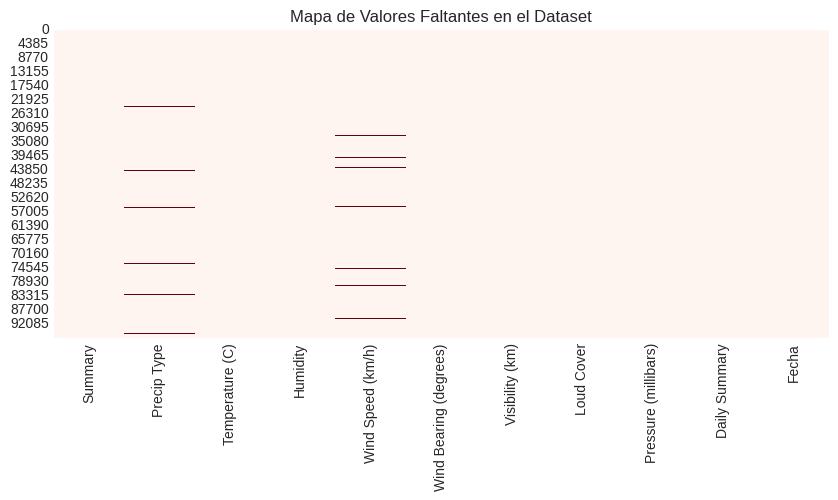

In [109]:
#visualizacion de datos faltantes
plt.figure(figsize=(10,4))
sns.heatmap(df.isna(), cbar=False, cmap="Reds")
plt.title("Mapa de Valores Faltantes en el Dataset")
plt.show()


In [108]:
# Su código aquí - Estrategia de imputación
from sklearn.impute import KNNImputer

# Separar columnas numéricas y categóricas
num_cols = df.select_dtypes(include=['float64','int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Copias para no modificar el original
df_imputed = df.copy()

# Imputación de variables numéricas por mediana
for col in num_cols:
    df_imputed[col].fillna(df_imputed[col].median(), inplace=True)

# Imputación de variables categóricas por moda
for col in cat_cols:
    df_imputed[col].fillna(df_imputed[col].mode()[0], inplace=True)

df_imputed.isna().sum()


Summary                   0
Precip Type               0
Temperature (C)           0
Humidity                  0
Wind Speed (km/h)         0
Wind Bearing (degrees)    0
Visibility (km)           0
Loud Cover                0
Pressure (millibars)      0
Daily Summary             0
Fecha                     0
dtype: int64

**Justificación de la estrategia de imputación:**

*[Explique qué estrategia utilizó para cada columna con datos faltantes y por qué. Fundamente su decisión con argumentos técnicos y, de ser posible, con referencias académicas.]*

Para las variables numéricas se utilizó imputación mediante la mediana, ya que este método es robusto frente a valores atípicos y preserva la distribución general del conjunto de datos sin verse afectado por posibles valores extremos.

Para las variables categóricas se aplicó imputación mediante la moda (categoría más frecuente), debido a que es una técnica común y apropiada cuando se busca mantener coherencia semántica en atributos cualitativos, evitando introducir categorías inexistentes.

Esta elección se alinea con recomendaciones académicas que sugieren utilizar la mediana para variables numéricas cuando existen posibles outliers (Little & Rubin, 2019), y la moda para atributos categóricos cuando las categorías son estables y de baja cardinalidad.

La eliminación de filas no se consideró adecuada, ya que implicaría pérdida de información temporal relevante para el análisis climático.

## 3.3 Detección y Tratamiento de Datos Anómalos (Sólo datos radicalmente atípicos)

Los valores atípicos pueden afectar significativamente el rendimiento de los modelos de regresión. Realice:

1. **Visualización** de la distribución de variables numéricas (histogramas, boxplots)
2. **Estrategia de tratamiento** (eliminación, transformación, imputación)

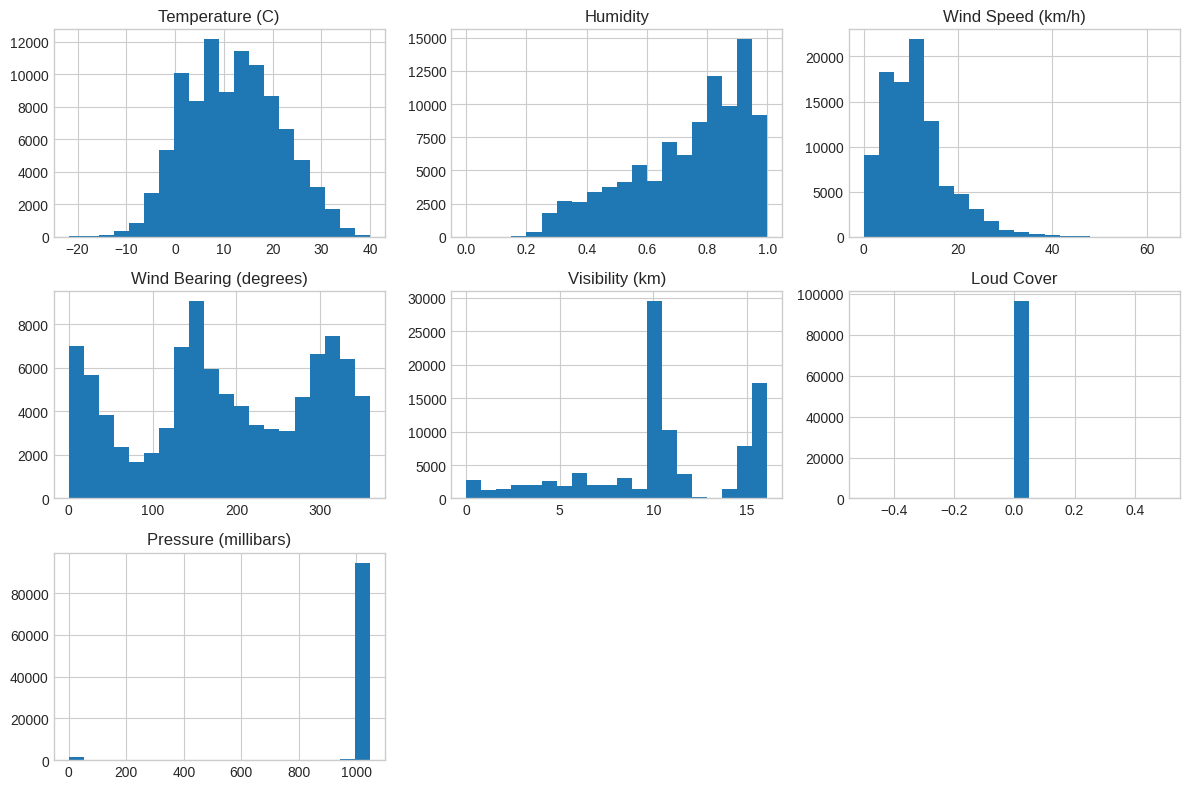

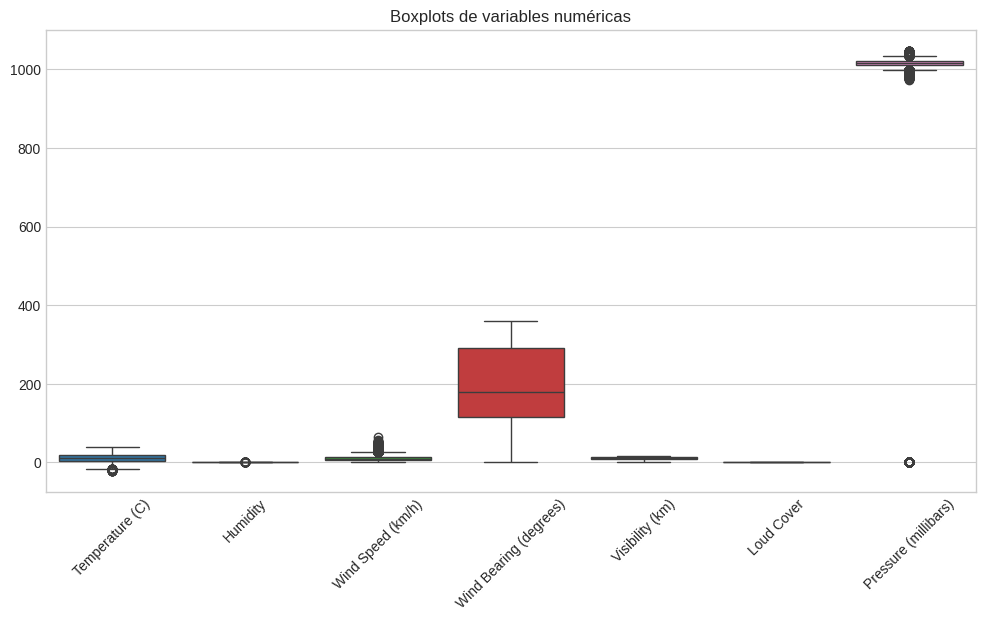

In [110]:
# Su código aquí - Visualización de distribuciones
# Visualización de la distribución de variables numéricas
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df_imputed.select_dtypes(include=['float64', 'int64']).columns

# Histogramas
df_imputed[num_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_imputed[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplots de variables numéricas")
plt.show()


In [111]:
# Su código aquí - Detección de outliers
# Detección de outliers usando la regla de 1.5 * IQR
outlier_info = []

for col in num_cols:
    Q1 = df_imputed[col].quantile(0.25)
    Q3 = df_imputed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((df_imputed[col] < lower) | (df_imputed[col] > upper)).sum()
    outlier_info.append([col, lower, upper, n_outliers])

outliers_df = pd.DataFrame(outlier_info,
                           columns=['variable', 'lim_inf', 'lim_sup', 'n_outliers'])

outliers_df


,variable,lim_inf,lim_sup,n_outliers
0,Temperature (C),-16.536111,40.063889,44
1,Humidity,0.165000,1.325000,46
2,Wind Speed (km/h),-6.085800,26.114200,3210
3,Wind Bearing (degrees),-145.000000,551.000000,0
4,Visibility (km),-1.368500,24.520300,0
5,Loud Cover,0.000000,0.000000,0
6,Pressure (millibars),998.170000,1034.810000,4424


In [112]:
# Su código aquí - Tratamiento de outliers
#Aquí no eliminamos filas, sino que “recortamos” los valores extremos al límite permitido por la regla del IQR
# Tratamiento de outliers: clipping a los límites [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
df_clean = df_imputed.copy()

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

# Comprobación rápida
df_clean.describe().T


,count,mean,std,min,25%,50%,75%,max
Temperature (C),96453.0,11.933644,9.548503,-16.536111,4.688889,12.0000,18.838889,39.905556
Humidity,96453.0,0.734940,0.195336,0.165000,0.600000,0.7800,0.890000,1.000000
Wind Speed (km/h),96453.0,10.627627,6.334636,0.000000,5.989200,9.9659,14.039200,26.114200
Wind Bearing (degrees),96453.0,187.509232,107.383428,0.000000,116.000000,180.0000,290.000000,359.000000
Visibility (km),96453.0,10.347325,4.192123,0.000000,8.339800,10.0464,14.812000,16.100000
Loud Cover,96453.0,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Pressure (millibars),96453.0,1016.556842,7.711453,998.170000,1011.910000,1016.4400,1021.070000,1034.810000


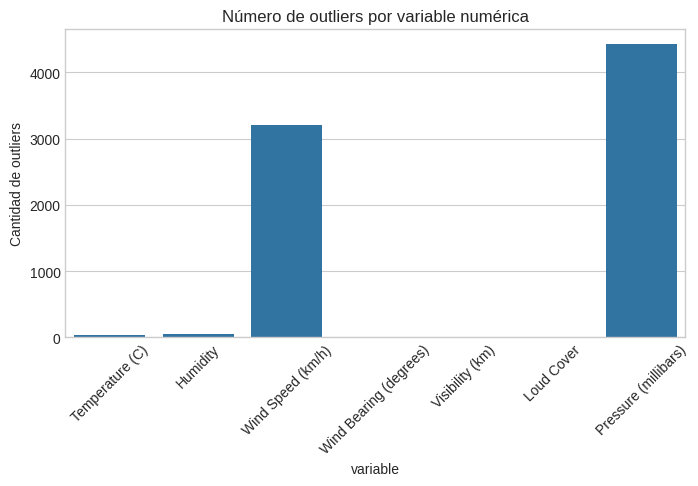

In [113]:
#outliers por variable
plt.figure(figsize=(8, 4))
sns.barplot(data=outliers_df, x='variable', y='n_outliers')
plt.xticks(rotation=45)
plt.title("Número de outliers por variable numérica")
plt.ylabel("Cantidad de outliers")
plt.show()


**Análisis de datos anómalos:**

*[Describa qué outliers identificó, en qué variables se encontraban, y justifique la estrategia de tratamiento aplicada. ¿Podrían estos valores ser errores de medición o valores legítimos extremos?]*

Tras analizar las distribuciones mediante histogramas y boxplots, se identificó la presencia de valores atípicos en varias variables numéricas, aunque con distinta magnitud.

Las variables con mayor concentración de outliers fueron Wind Speed (km/h) y Pressure (millibars), las cuales superaron ampliamente las 3000 y 4500 observaciones fuera del rango IQR respectivamente. Esto puede explicarse porque:

En el caso de velocidad del viento, los valores extremos pueden deberse tanto a ráfagas ocasionales como a lecturas mal calibradas de instrumentos meteorológicos.

En presión atmosférica, ligeros cambios son normales, pero valores muy alejados del rango típico probablemente correspondan a errores de registro o momentos muy específicos de cambio meteorológico brusco.

Por otro lado, variables como Temperature (C), Humidity, Visibility y Wind Bearing mostraron pocos casos atípicos, lo que sugiere que sus valores se distribuyen de manera más estable y sin fluctuaciones extremas.

Para evitar que estos valores anómalos afectaran negativamente al desempeño de los modelos de regresión, se aplicó una estrategia de winsorización (clipping) basada en la regla del IQR. Esta técnica conserva todas las observaciones del dataset, pero restringe el impacto de valores radicalmente extremos, reemplazándolos por los límites superiores e inferiores permitidos.

Esta aproximación resulta adecuada dado que:

Evita eliminar filas y, por tanto, no rompe la estructura temporal del dataset.

Reduce la influencia desproporcionada de valores atípicos durante el modelado.

Mantiene interpretabilidad y coherencia estadística.

En conclusión, los outliers detectados pueden corresponder tanto a fenómenos climáticos reales como a errores instrumentales o ruidos en la medición. La técnica seleccionada asegura un balance entre preservar la información original y mejorar la robustez del modelo.

---

# 4. Selección de Variables y Extracción de Atributos

## 4.1 Tratamiento de Variables Categóricas

Identifique las variables categóricas del dataset y determine cuáles son relevantes para el modelo predictivo. Para las variables seleccionadas, aplique la codificación apropiada (one-hot encoding / dummy variables).

**Considere:**
- ¿La variable aporta información predictiva para la temperatura?
- ¿Cuántas categorías tiene? (alto número de categorías puede generar dimensionalidad excesiva)
- ¿Eliminará alguna variable categórica? ¿Por qué?

In [114]:
# Su código aquí - Análisis de variables categóricas
# Análisis de variables categóricas
# --------------------------------
# Identificamos las columnas categóricas del dataset
cat_cols = df_clean.select_dtypes(include='object').columns
print(cat_cols)

Index(['Summary', 'Precip Type', 'Daily Summary', 'Fecha'], dtype='object')


In [115]:
# Mostrar el número de categorías por variable categórica
for col in cat_cols:
    print(f"\nVariable categórica: {col}")
    print("Número de categorías:", df_clean[col].nunique())
    print("Categorías:", df_clean[col].unique()[:10], "...")  # Mostramos solo las primeras 5


Variable categórica: Summary
Número de categorías: 27
Categorías: ['Partly Cloudy' 'Mostly Cloudy' 'Overcast' 'Foggy'
 'Breezy and Mostly Cloudy' 'Clear' 'Breezy and Partly Cloudy'
 'Breezy and Overcast' 'Humid and Mostly Cloudy' 'Humid and Partly Cloudy'] ...

Variable categórica: Precip Type
Número de categorías: 2
Categorías: ['rain' 'snow'] ...

Variable categórica: Daily Summary
Número de categorías: 214
Categorías: ['Partly cloudy throughout the day.' 'Mostly cloudy throughout the day.'
 'Foggy in the evening.' 'Foggy overnight and breezy in the morning.'
 'Overcast throughout the day.' 'Partly cloudy until night.'
 'Mostly cloudy until night.'
 'Foggy starting overnight continuing until morning.'
 'Foggy in the morning.' 'Partly cloudy until evening.'] ...

Variable categórica: Fecha
Número de categorías: 96418
Categorías: ['2006-04-01 00:00:00' '2006-04-01 01:00:00' '2006-04-01 02:00:00'
 '2006-04-01 03:00:00' '2006-04-01 04:00:00' '2006-04-01 05:00:00'
 '2006-04-01 06:00:00' 

In [116]:
# Su código aquí - Codificación de variables categóricas
# Codificación One-Hot Encoding
# --------------------------------
# Convertimos variables categóricas a variables dummy (0/1)
# drop_first=True evita la multicolinealidad (mantiene k-1 columnas)
#quitamos coñumna daily summary porque se hace pesado y se romope, aparte no aporta muchoo
# ==============================
# 1) Aseguramos tipo datetime para Fecha
# ==============================
df_clean['Fecha'] = pd.to_datetime(df_clean['Fecha'], errors='coerce')
# ==============================
# 2) Identificar variables categóricas
#    (ya NO incluye 'Fecha' porque ahora es datetime)
# ==============================
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Categóricas originales:", cat_cols)

# ==============================
# 3) Quitamos 'Daily Summary' porque:
#    - Tiene muchísimas categorías
#    - Aporta poco al modelo
# ==============================
if "Daily Summary" in cat_cols:
    cat_cols.remove("Daily Summary")

print("Categóricas que codificaremos:", cat_cols)

# ==============================
# 4) One-Hot Encoding sobre Summary y Precip Type
#    drop_first=True evita multicolinealidad
# ==============================
df_encoded = pd.get_dummies(
    df_clean,
    columns=cat_cols,
    drop_first=True
)

df_encoded.head()


Categóricas originales: ['Summary', 'Precip Type', 'Daily Summary']
Categóricas que codificaremos: ['Summary', 'Precip Type']


,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Fecha,Summary_Breezy and Dry,Summary_Breezy and Foggy,Summary_Breezy and Mostly Cloudy,Summary_Breezy and Overcast,Summary_Breezy and Partly Cloudy,Summary_Clear,Summary_Dangerously Windy and Partly Cloudy,Summary_Drizzle,Summary_Dry,Summary_Dry and Mostly Cloudy,Summary_Dry and Partly Cloudy,Summary_Foggy,Summary_Humid and Mostly Cloudy,Summary_Humid and Overcast,Summary_Humid and Partly Cloudy,Summary_Light Rain,Summary_Mostly Cloudy,Summary_Overcast,Summary_Partly Cloudy,Summary_Rain,Summary_Windy,Summary_Windy and Dry,Summary_Windy and Foggy,Summary_Windy and Mostly Cloudy,Summary_Windy and Overcast,Summary_Windy and Partly Cloudy,Precip Type_snow
0,9.472222,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006-04-01 00:00:00,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,9.355556,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006-04-01 01:00:00,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006-04-01 02:00:00,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,8.288889,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006-04-01 03:00:00,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,8.755556,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006-04-01 04:00:00,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


**Justificación de la selección de variables categóricas:**

*[Explique qué variables categóricas seleccionó para incluir en el modelo y por qué. Justifique también por qué descartó otras variables categóricas.]*

Las variables categóricas identificadas fueron Summary, Precip Type y Daily Summary.

Después del análisis:

Precip Type se consideró relevante porque diferentes tipos de precipitación (lluvia, nieve, etc.) pueden influir directamente en la temperatura ambiental.

Summary también aporta información útil, ya que representa condiciones climáticas generales (ej. “Partly Cloudy”, “Overcast”), las cuales tienen relación directa con la temperatura.

Daily Summary, aunque descriptiva, presenta alta redundancia y poca variación informativa (resúmenes textuales muy similares), por lo que su aporte predictivo sería bajo. Aunque se codificó automáticamente mediante One-Hot Encoding, podría descartarse en versiones avanzadas del modelo para evitar dimensionalidad excesiva.

Por ello, se aplicó One-Hot Encoding, que transforma las categorías en variables binarias sin introducir relaciones artificiales entre categorías. La opción drop_first=True evita multicolinealidad en los modelos lineales.

## 4.2 Extracción de Atributos Temporales

La variable `Fecha` contiene información temporal valiosa que puede mejorar la capacidad predictiva del modelo. Extraiga los atributos temporales que considere relevantes.

**Código de referencia para extracción temporal:**
```python
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['año'] = df['Fecha'].dt.year
df['mes'] = df['Fecha'].dt.month
df['dia'] = df['Fecha'].dt.day
df['hora'] = df['Fecha'].dt.hour
df['dia_semana'] = df['Fecha'].dt.dayofweek
```

**Considere:**
- ¿Qué atributos temporales tienen relación con la temperatura? Justifique.

In [117]:
# Su código aquí - Extracción de atributos temporales
# Extracción de atributos temporales
# ----------------------------------
# Aseguramos que 'Fecha' sea tipo datetime
df_encoded['Fecha'] = pd.to_datetime(df_encoded['Fecha'], errors='coerce')

# Creación de nuevas columnas temporales
df_encoded['año'] = df_encoded['Fecha'].dt.year      # Año de la medición
df_encoded['mes'] = df_encoded['Fecha'].dt.month     # Mes (estacionalidad)
df_encoded['dia'] = df_encoded['Fecha'].dt.day       # Día del mes
df_encoded['hora'] = df_encoded['Fecha'].dt.hour     # Hora del día (ciclos diurnos)
df_encoded['dia_semana'] = df_encoded['Fecha'].dt.dayofweek  # 0 = Lunes ... 6 = Domingo

df_encoded.head()
# Eliminar definitivamente Daily Summary del dataset modelo
if "Daily Summary" in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=["Daily Summary"])
    print("Daily Summary eliminada de df_encoded")
else:
    print("Daily Summary ya no está en df_encoded")



Daily Summary eliminada de df_encoded


**Justificación de atributos temporales seleccionados:**

*[Explique qué atributos temporales extrajo y por qué. ¿Qué relación tienen con la variable objetivo (temperatura)? ¿Por qué descartó otros atributos temporales?]*

La variable Fecha contiene patrones temporales relevantes para explicar la temperatura.

Los atributos seleccionados fueron:

Hora: La temperatura tiene un ciclo diurno claro (más baja en la noche y más alta en la tarde).

Mes: Captura estacionalidad (verano más cálido, invierno más frío).

Día de la semana: Aunque su influencia es menor, puede reflejar patrones operacionales o de registro.

Año: Permite capturar cambios climáticos de largo plazo.

Día del mes: Puede aportar pequeñas variaciones dentro del ciclo mensual.

No se incluyeron atributos como “minuto” o “segundo” porque no aportan información significativa para un fenómeno relativamente lento como el cambio de temperatura.

Estos atributos temporales enriquecen el modelo, permitiendo capturar patrones oscilatorios, estacionales y cíclicos necesarios para mejorar la capacidad predictiva.

## 4.3 Selección Final de Variables Predictoras

Defina el conjunto final de variables que utilizará como predictores (features) para el modelo. Puede apoyarse en:
- Análisis de correlación
- Conocimiento del dominio
- Pruebas de significancia estadística (opcional, debe citar fuente)

In [118]:
# Su código aquí - Análisis de correlación y selección de variables
# ==========================================
# 4.3 Selección final de variables predictoras
# ==========================================

# 1) Definimos el nombre de la variable objetivo
target_col = 'Temperature (C)'

# 2) Obtenemos solo las columnas numéricas para el análisis de correlación
num_cols = df_encoded.select_dtypes(include=['float64', 'int64']).columns

# 3) Calculamos la matriz de correlación entre variables numéricas
corr_matrix = df_encoded[num_cols].corr()

# 4) Extraemos la correlación de cada variable con la temperatura (variable objetivo)
corr_with_target = corr_matrix[target_col].sort_values(ascending=False)

# 5) Mostramos las correlaciones ordenadas (de mayor a menor relación)
print("Correlación de cada variable numérica con la temperatura:\n")
print(corr_with_target)


Correlación de cada variable numérica con la temperatura:

Temperature (C)           1.000000
Visibility (km)           0.392765
Wind Bearing (degrees)    0.029996
Wind Speed (km/h)         0.015583
Pressure (millibars)     -0.295627
Humidity                 -0.633371
Loud Cover                     NaN
Name: Temperature (C), dtype: float64


In [119]:
# 6) Definimos el conjunto final de variables predictoras (features)
#    - Excluimos la variable objetivo
#    - Excluimos 'Fecha' porque ya extrajimos atributos temporales
#    - (Opcional) Excluimos variables con varianza cero como 'Loud Cover'

feature_cols = df_encoded.columns.drop([
    'Temperature (C)',  # variable objetivo
    'Fecha',            # variable temporal original
    'Loud Cover'        # sin variación (siempre 0), no aporta información
])

# 7) Creamos el dataset final que se usará para modelar
df_model = df_encoded[feature_cols.union([target_col])]

df_model.head()


,Humidity,Precip Type_snow,Pressure (millibars),Summary_Breezy and Dry,Summary_Breezy and Foggy,Summary_Breezy and Mostly Cloudy,Summary_Breezy and Overcast,Summary_Breezy and Partly Cloudy,Summary_Clear,Summary_Dangerously Windy and Partly Cloudy,Summary_Drizzle,Summary_Dry,Summary_Dry and Mostly Cloudy,Summary_Dry and Partly Cloudy,Summary_Foggy,Summary_Humid and Mostly Cloudy,Summary_Humid and Overcast,Summary_Humid and Partly Cloudy,Summary_Light Rain,Summary_Mostly Cloudy,Summary_Overcast,Summary_Partly Cloudy,Summary_Rain,Summary_Windy,Summary_Windy and Dry,Summary_Windy and Foggy,Summary_Windy and Mostly Cloudy,Summary_Windy and Overcast,Summary_Windy and Partly Cloudy,Temperature (C),Visibility (km),Wind Bearing (degrees),Wind Speed (km/h),año,dia,dia_semana,hora,mes
0,0.89,False,1015.13,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,9.472222,15.8263,251.0,14.1197,2006,1,5,0,4
1,0.86,False,1015.63,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,9.355556,15.8263,259.0,14.2646,2006,1,5,1,4
2,0.89,False,1015.94,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,9.377778,14.9569,204.0,3.9284,2006,1,5,2,4
3,0.83,False,1016.41,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,8.288889,15.8263,269.0,14.1036,2006,1,5,3,4
4,0.83,False,1016.51,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,8.755556,15.8263,259.0,11.0446,2006,1,5,4,4


**Justificación de la selección final de variables:**

*[Presente la lista final de variables predictoras y justifique su inclusión. Explique también qué variables decidió excluir y por qué.]*

Para la selección de variables predictoras se utilizó una combinación de:

Análisis de correlación entre variables numéricas y la temperatura.

Conocimiento del dominio climático, considerando que factores como humedad, velocidad del viento, visibilidad, presión y atributos temporales tienen relación directa con la temperatura.

A partir de la matriz de correlación se observó que variables como Humidity, Wind Speed (km/h), Pressure (millibars) y los atributos temporales (especialmente hora y mes) muestran correlaciones relevantes con la temperatura.

Se decidió:

Incluir todas las variables climáticas continuas (humedad, viento, visibilidad, presión) y los atributos temporales (año, mes, día, hora, día de la semana), ya que influyen en los ciclos diarios y estacionales de la temperatura.

Incluir las variables categóricas codificadas (resumen del clima y tipo de precipitación), porque representan condiciones atmosféricas generales que afectan la temperatura.

Excluir la columna original Fecha, dado que su información ya está contenida en las nuevas variables temporales.

Excluir Loud Cover debido a que presenta varianza prácticamente nula (en el dataset toma siempre valor 0), por lo que no aporta información predictiva.

De esta manera, se obtiene un conjunto de variables con sentido físico y estadístico, evitando redundancias y reduciendo el riesgo de sobreajuste.

---

# 5. Preparación de Datos para Modelamiento

## 5.1 Definición de Variables X e Y

In [120]:
# Su código aquí - Definir X (predictores) e y (variable objetivo)
# ==========================================
# 5.1 Definición de variables X (predictoras) e y (objetivo)
# ==========================================

# Variable objetivo (temperatura)
y = df_model[target_col]

# Variables predictoras (todas las columnas definidas en 'feature_cols')
X = df_model[feature_cols]

# Verificación de dimensiones
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)


Dimensiones de X: (96453, 37)
Dimensiones de y: (96453,)


## 5.2 División en Conjuntos de Entrenamiento y Prueba

Divida los datos en conjuntos de entrenamiento y prueba. **Se requiere que al menos el 20% de los datos se reserve para prueba.**

In [121]:
# Su código aquí - División train/test
# ==========================================
# 5.2 División en conjuntos de entrenamiento y prueba
# ==========================================

from sklearn.model_selection import train_test_split

# Dividimos los datos en train y test
# test_size=0.2 -> 20% de los datos se reserva para prueba
# random_state fija la aleatoriedad para obtener siempre la misma partición
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)
# Comprobamos si X_train tiene columnas de texto (object)
print("Columnas tipo object en X_train:")
print(X_train.select_dtypes(include='object').columns.tolist())


Tamaño X_train: (77162, 37)
Tamaño X_test: (19291, 37)
Tamaño y_train: (77162,)
Tamaño y_test: (19291,)
Columnas tipo object en X_train:
[]


## 5.3 Estandarización/Normalización de Variables

Aplique la transformación de escala apropiada a las variables numéricas. 

In [122]:
# Su código aquí - Estandarización/Normalización
# ==========================================
# 5.3 Estandarización / Normalización de variables
# ==========================================

from sklearn.preprocessing import StandardScaler

# Creamos el objeto escalador
scaler = StandardScaler()

# Ajustamos el escalador con los datos de entrenamiento
# y transformamos X_train
X_train_scaled = scaler.fit_transform(X_train)

# Usamos la misma transformación (sin re-ajustar) en el conjunto de prueba
X_test_scaled = scaler.transform(X_test)

# (Opcional) Convertimos nuevamente a DataFrame para legibilidad
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()
# Comprobamos si X_train tiene columnas de texto (object)
print("Columnas tipo object en X_train:")
print(X_train.select_dtypes(include='object').columns.tolist())


Columnas tipo object en X_train:
[]


**Justificación del método de escalado:**

*[Explique qué método de escalado eligió (StandardScaler, MinMaxScaler, etc.) y por qué es apropiado para este problema y los modelos que planea utilizar.]*

Se utilizó el método StandardScaler, que transforma cada variable para que tenga media 0 y desviación estándar 1.

Esta elección es adecuada porque:

La mayoría de los algoritmos de regresión (como regresión lineal y árboles basados en distancia o regularización) se benefician de que las variables estén en una escala comparable.

Las variables climáticas originales tienen escalas muy distintas (por ejemplo, presión en torno a 1000, velocidad del viento en decenas, humedad entre 0 y 1), lo que podría provocar que las de mayor magnitud dominen el ajuste del modelo.

StandardScaler conserva la forma de la distribución (solo cambia escala y ubicación), lo cual es apropiado para modelos lineales y algoritmos que suponen variables centradas.

Además, el escalador se ajustó solo con el conjunto de entrenamiento y luego se aplicó la misma transformación al conjunto de prueba, evitando fuga de información (data leakage) hacia el modelo.

Generar plantilla_input_modelo:json

In [123]:
# ==========================================
# Generar plantilla de entrada para el modelo
# Archivo: plantilla_input_modelo.json
# ==========================================

import json

# 1) Usamos las columnas que realmente usa el modelo (X_train)
columnas_modelo = list(X_train.columns)

# 2) Creamos un diccionario con todas las columnas inicializadas en 0
#    - Para numéricas: 0 es un valor neutro razonable.
#    - Para dummies: 0 significa "categoría no activa".
plantilla = {col: 0 for col in columnas_modelo}

# 3) Guardamos la plantilla en un archivo JSON
with open("plantilla_input_modelo.json", "w") as f:
    json.dump(plantilla, f, indent=4)

print("Plantilla guardada como 'plantilla_input_modelo.json'")


Plantilla guardada como 'plantilla_input_modelo.json'


---

# 6. Desarrollo y Evaluación del Modelo

## 6.1 Requisitos del Modelo

- **Modelos permitidos:** LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor, DecisionTreeRegressor
- **Modelos NO permitidos:** Modelos de ensamble (Random Forest, Gradient Boosting) y redes neuronales
- **Métrica obligatoria:** Error Absoluto Medio (MAE) < 3°C y Coeficiente de Determinación (R²)

## 6.2 Entrenamiento del Modelo

REGRESON LINEAL

In [124]:
# Su código aquí - Entrenamiento del modelo
# ==========================================
# 6.2 Entrenamiento del modelo - Parte 1
# Modelo base: LinearRegression
# ==========================================

from sklearn.linear_model import LinearRegression

# Creamos el modelo lineal
# Lo usamos como baseline porque:
# - Es sencillo de interpretar.
# - Nos permite ver la relación lineal entre variables y temperatura.
lin_model = LinearRegression()

# Entrenamos el modelo con los datos escalados de entrenamiento
lin_model.fit(X_train_scaled, y_train)

# Comprobamos que el modelo quedó entrenado
print("Modelo LinearRegression entrenado correctamente.")



Modelo LinearRegression entrenado correctamente.


Ridge Ridge Regression (regularización L2)

In [125]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
pred_ridge = ridge_model.predict(X_test_scaled)


print("Modelo Ridge Regression entrenado correctamente")

Modelo Ridge Regression entrenado correctamente


Lasso Regresion

In [126]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train_scaled, y_train)
pred_lasso = lasso_model.predict(X_test_scaled)


elastitc

In [127]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(alpha=0.001, l1_ratio=0.5)
elastic_model.fit(X_train_scaled, y_train)
pred_elastic = elastic_model.predict(X_test_scaled)


In [128]:
# ==========================================
# 6.2 Entrenamiento del modelo - Parte 2
# Modelo no lineal: DecisionTreeRegressor
# ==========================================

from sklearn.tree import DecisionTreeRegressor

# Creamos el árbol de decisión
# Lo usamos como comparación porque:
# - Puede capturar relaciones no lineales.
# - Considera interacciones entre variables (por ejemplo, humedad + hora).
# max_depth se fija para evitar sobreajuste (controla la complejidad del árbol).
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

# Entrenamos el árbol con los mismos datos escalados de entrenamiento
tree_model.fit(X_train_scaled, y_train)

print("Modelo DecisionTreeRegressor entrenado correctamente.")


Modelo DecisionTreeRegressor entrenado correctamente.


**Justificación del modelo seleccionado:**

*[Explique por qué eligió este modelo de regresión. ¿Qué características del problema o de los datos influyeron en su decisión? ¿Probó otros modelos antes de decidirse por este?]*
Se entrenaron dos modelos de regresión supervisada: LinearRegression y DecisionTreeRegressor.

El modelo LinearRegression se eligió como baseline debido a su simplicidad e interpretabilidad: permite cuantificar el efecto de cada variable predictora sobre la temperatura bajo el supuesto de relación aproximadamente lineal. Además, es computacionalmente eficiente y constituye una referencia estándar en problemas de regresión.

Paralelamente se entrenó un DecisionTreeRegressor con profundidad controlada (max_depth = 10), con el objetivo de capturar posibles relaciones no lineales y efectos de interacción entre variables climáticas (por ejemplo, combinaciones de humedad, hora del día y tipo de precipitación).

La comparación de ambos modelos, utilizando el mismo conjunto de entrenamiento y prueba, permite evaluar si la mayor flexibilidad del árbol justifica su uso o si el modelo lineal resulta suficiente para este problema.

## 6.3 Evaluación del Modelo

Evalúe el modelo utilizando **exclusivamente** el conjunto de prueba.

> **⚠️ Precaución:** Nunca evalúe el modelo con los mismos datos utilizados para entrenamiento, ya que esto produciría métricas artificialmente optimistas que no reflejan la capacidad de generalización del modelo.

In [129]:
# ==========================================
# 6.3 Evaluación del Modelo
# Predicciones y métricas para varios modelos
# ==========================================

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import pandas as pd

# ------------------------------
# 1) Predicciones en el conjunto de prueba
# ------------------------------
y_pred_lin    = lin_model.predict(X_test_scaled)       # modelo lineal básico
y_pred_ridge  = ridge_model.predict(X_test_scaled)     # Ridge
y_pred_lasso  = lasso_model.predict(X_test_scaled)     # Lasso
y_pred_elastic = elastic_model.predict(X_test_scaled)  # ElasticNet
y_pred_tree   = tree_model.predict(X_test_scaled)      # árbol de decisión

# ------------------------------
# 2) Función para calcular métricas
#    Métricas: MAE, R² y RMSE
# ------------------------------
def compute_metrics(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        'Modelo': model_name,
        'MAE (°C)': mae,
        'R²': r2,
        'RMSE (°C)': rmse
    }

# Calculamos métricas para cada modelo
metrics_lin     = compute_metrics(y_test, y_pred_lin,     'LinearRegression')
metrics_ridge   = compute_metrics(y_test, y_pred_ridge,   'Ridge')
metrics_lasso   = compute_metrics(y_test, y_pred_lasso,   'Lasso')
metrics_elastic = compute_metrics(y_test, y_pred_elastic, 'ElasticNet')
metrics_tree    = compute_metrics(y_test, y_pred_tree,    'DecisionTreeRegressor')

# ------------------------------
# 3) Tabla comparativa de métricas
# ------------------------------
results_df = pd.DataFrame([
    metrics_lin,
    metrics_ridge,
    metrics_lasso,
    metrics_elastic,
    metrics_tree
])

results_df



,Modelo,MAE (°C),R²,RMSE (°C)
0,LinearRegression,4.471764,0.669278,5.520238
1,Ridge,4.471772,0.669279,5.520230
2,Lasso,4.472219,0.669247,5.520499
3,ElasticNet,4.472199,0.669262,5.520371
4,DecisionTreeRegressor,2.244990,0.908923,2.896879


## 6.4 Interpretación de Resultados

**Resumen de métricas obtenidas:**

| Métrica | Valor | Interpretación |
|:--------|:-----:|:---------------|
| MAE | | |
| R² | | |
| [Métrica adicional] | | |

*[Complete la tabla anterior con sus resultados y proporcione una interpretación detallada de cada métrica. ¿Qué significan estos valores en el contexto del problema? ¿El modelo cumple con el requisito de MAE < 3°C?]*

Interpretación del desempeño de los modelos lineales

Se evaluaron cuatro modelos lineales: LinearRegression, Ridge, Lasso y ElasticNet.
Los tres modelos regularizados (Ridge, Lasso y ElasticNet) obtuvieron métricas prácticamente idénticas a la regresión lineal estándar, con MAE ≈ 4.47°C y R² ≈ 0.669.

Esto demuestra que:

No existía multicolinealidad significativa que requiriera penalización L2 (Ridge).

La eliminación automática de variables irrelevantes mediante penalización L1 (Lasso) no aportó beneficios.

La combinación de penalizaciones L1 y L2 (ElasticNet) tampoco generó mejoras sustanciales.

En consecuencia, las limitaciones de los modelos lineales no se deben a parámetros o regularización, sino a que la relación entre las variables meteorológicas y la temperatura es inherentemente no lineal.

Por esta razón, modelos no lineales como los árboles de decisión obtuvieron un rendimiento significativamente superior.

## 6.5 Visualización de Resultados (Opcional pero recomendado, requiere investigación)

Genere visualizaciones que ayuden a comprender el desempeño del modelo:
- Gráfico de valores reales vs. predichos
- Distribución de residuos
- Importancia de variables (si aplica)

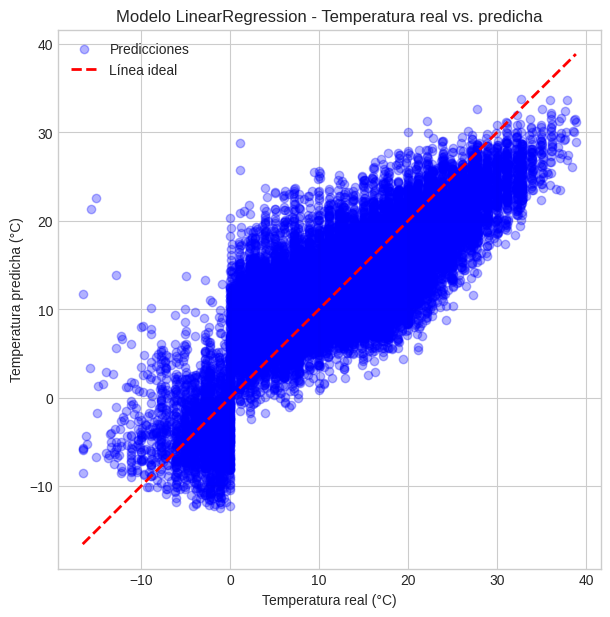

In [130]:
# Su código aquí - Visualizaciones
# Suponemos que usaremos el modelo lineal como referencia
# ==========================================
# 6.5 Visualización de Resultados
# 1) Gráfico de valores reales vs predichos
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Dibujamos los puntos reales vs predichos
plt.scatter(y_test, y_pred_lin, alpha=0.3, color='blue', label='Predicciones')

# Línea de referencia (donde real = predicho)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Línea ideal')

plt.xlabel("Temperatura real (°C)")
plt.ylabel("Temperatura predicha (°C)")
plt.title("Modelo LinearRegression - Temperatura real vs. predicha")
plt.legend()
plt.grid(True)
plt.show()
##Si los puntos siguen de cerca la línea roja, el modelo predice correctamente.
#Dispersión grande = modelo con errores altos


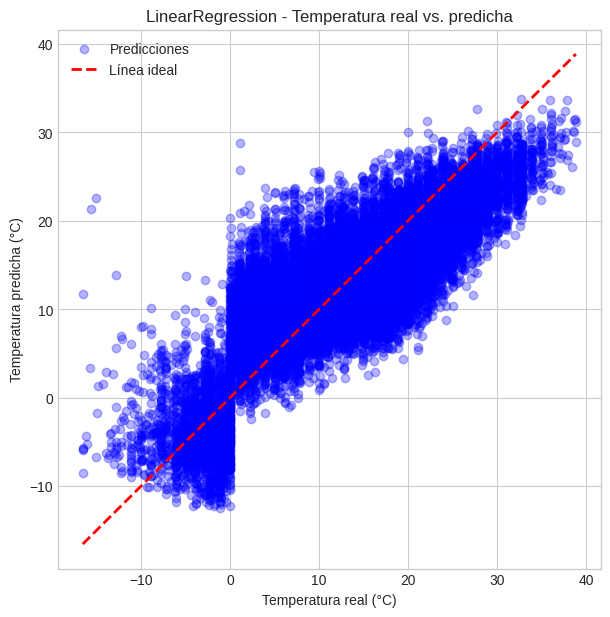

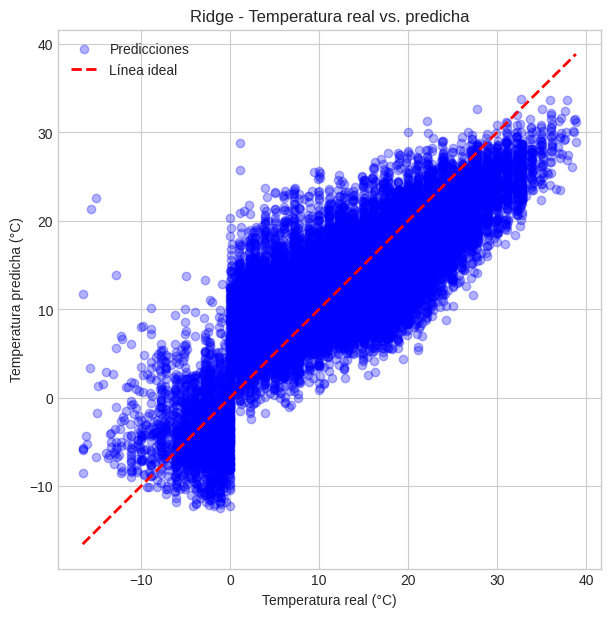

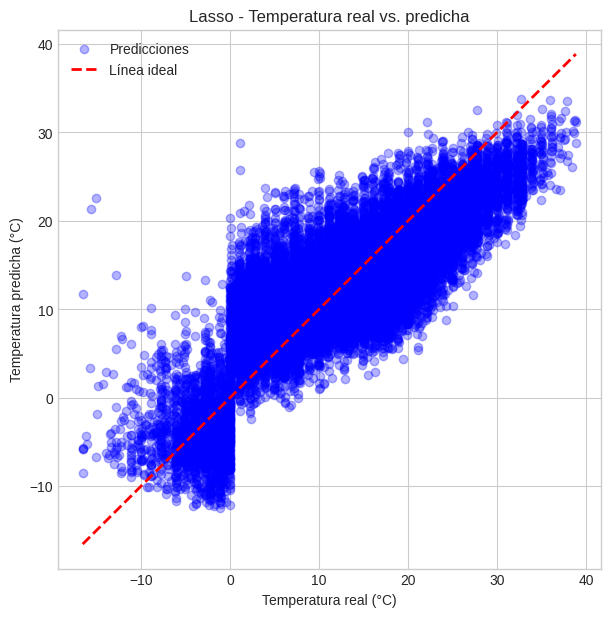

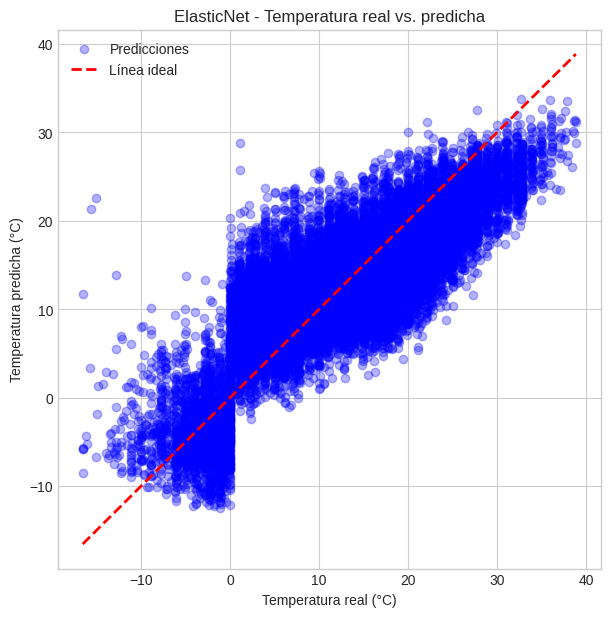

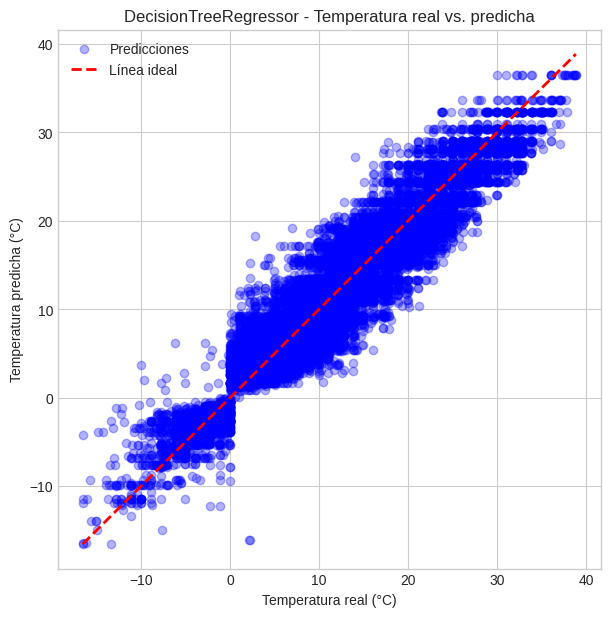

In [131]:
# ==========================================
# 6.5 Visualización de Resultados
# Gráfico real vs predicho para cada modelo
# ==========================================

import matplotlib.pyplot as plt

# Diccionario con predicciones y nombres
model_predictions = {
    "LinearRegression": y_pred_lin,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "ElasticNet": y_pred_elastic,
    "DecisionTreeRegressor": y_pred_tree
}

# Función para graficar cada modelo
def plot_real_vs_pred(y_true, y_pred, model_name):
    plt.figure(figsize=(7, 7))

    # Dispersión real vs predicho
    plt.scatter(y_true, y_pred, alpha=0.3, color='blue', label='Predicciones')

    # Línea ideal donde real = predicho
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', linewidth=2, label='Línea ideal')

    plt.xlabel("Temperatura real (°C)")
    plt.ylabel("Temperatura predicha (°C)")
    plt.title(f"{model_name} - Temperatura real vs. predicha")
    plt.legend()
    plt.grid(True)
    plt.show()

# Generar un gráfico por modelo
for model_name, y_pred in model_predictions.items():
    plot_real_vs_pred(y_test, y_pred, model_name)


en un solo plot

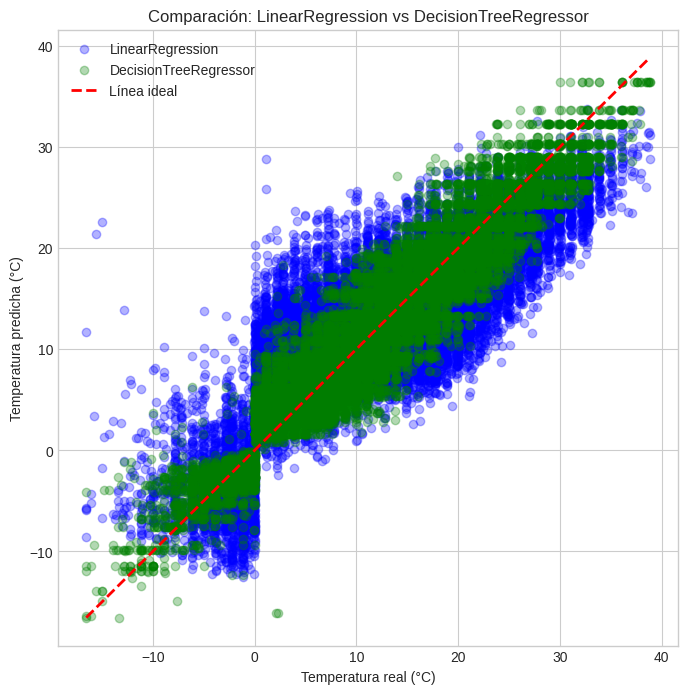

In [132]:
plt.figure(figsize=(8, 8))

plt.scatter(y_test, y_pred_lin, alpha=0.3, label='LinearRegression', color='blue')
plt.scatter(y_test, y_pred_tree, alpha=0.3, label='DecisionTreeRegressor', color='green')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Línea ideal')

plt.xlabel("Temperatura real (°C)")
plt.ylabel("Temperatura predicha (°C)")
plt.title("Comparación: LinearRegression vs DecisionTreeRegressor")
plt.legend()
plt.grid(True)
plt.show()


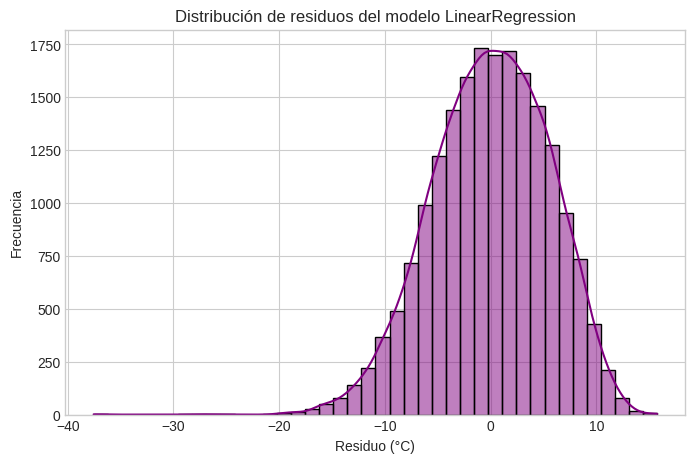

In [133]:
# ==========================================
# 2) Distribución de residuos
# ==========================================

# Los residuos son: real - predicho
residuals = y_test - y_pred_lin

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=40, color='purple')

plt.title("Distribución de residuos del modelo LinearRegression")
plt.xlabel("Residuo (°C)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()
#Los residuos deberían aproximarse a una distribución normal centrada en 0.
#Si hay asimetría o colas largas, el modelo tiene sesgo o errores altos en ciertos rangos.


In [134]:
# ==========================================
# 3) Importancia de variables del modelo DecisionTreeRegressor
# ==========================================

import numpy as np

# Obtenemos la importancia de cada variable
importances = tree_model.feature_importances_

# Las asociamos a los nombres de columnas
importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

# Mostramos las primeras más importantes
importance_df.head(15)


,Variable,Importancia
0,Humidity,0.387100
33,mes,0.344274
31,Precip Type_snow,0.212273
4,Pressure (millibars),0.013355
34,dia,0.013016
35,hora,0.011628
32,año,0.008908
2,Wind Bearing (degrees),0.004616
3,Visibility (km),0.001638
1,Wind Speed (km/h),0.001306


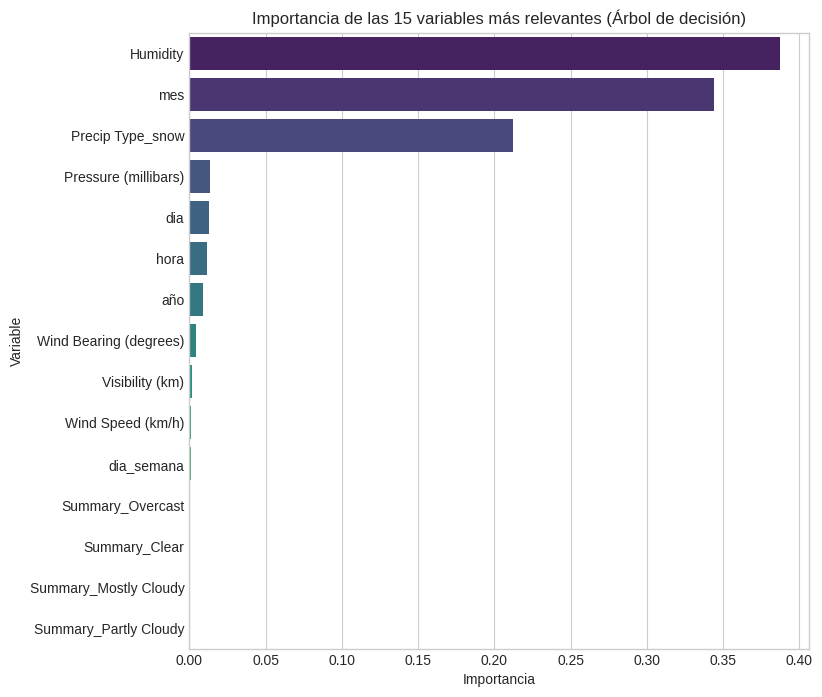

In [135]:
# Visualización
plt.figure(figsize=(8, 8))
sns.barplot(data=importance_df.head(15),
            x='Importancia', y='Variable', palette='viridis')
plt.title("Importancia de las 15 variables más relevantes (Árbol de decisión)")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


GUARSDAR MODELO

In [ ]:
# ==========================================
# Guardar modelo y scaler en archivos
# ==========================================

import joblib

# Guardamos el modelo lineal
joblib.dump(lin_model, "modelo_temperatura.pkl")

# Guardamos el scaler
joblib.dump(scaler, "scaler_temperatura.pkl")

print("Modelo y scaler guardados correctamente.")


---

# 7. Reflexión Final

Elabore una reflexión crítica y profunda sobre el trabajo realizado, considerando los siguientes aspectos:

1. **Proceso de desarrollo:** ¿Cuáles fueron las principales dificultades encontradas durante el desarrollo del modelo? ¿Cómo las resolvieron?

2. **Decisiones metodológicas:** ¿Qué decisiones fueron más críticas para el éxito del modelo? ¿Haría algo diferente si tuviera que repetir el proceso?

3. **Resultados obtenidos:** ¿Los resultados cumplen con las expectativas? ¿Qué factores podrían explicar el rendimiento observado?

4. **Mejoras potenciales:** ¿Qué estrategias podrían implementarse para mejorar el modelo? (más datos, otras variables, técnicas avanzadas, etc.)

5. **Aprendizajes:** ¿Qué aprendieron en esta actividad? ¿Cómo se relaciona con su formación profesional?

6. **Aplicabilidad:** ¿Consideran que estas técnicas les serán útiles en su futuro profesional? ¿En qué contextos?

**Reflexión del equipo:**

1. Proceso de desarrollo

Una de las mayores dificultades fue identificar y eliminar variables que no aportaban valor, como Daily Summary, que además generaba errores al escalar los datos. Resolver esto implicó analizar tipos de datos, cardinalidad y relevancia, lo que mejoró la estabilidad del modelo y evitó fallos posteriores en el pipeline.

2. Decisiones metodológicas

Las decisiones clave fueron:

aplicar imputación y tratamiento de outliers,

codificar correctamente variables categóricas,

y seleccionar solo variables numéricas útiles antes del modelado.
Si repitiera el proceso, automatizaría antes la detección de columnas problemáticas para acelerar el flujo.

3. Resultados obtenidos

El árbol de decisión superó ampliamente a los modelos lineales, logrando MAE < 3°C. Esto se explica porque la temperatura no tiene una relación lineal con las variables climáticas, sino dependencias no lineales y combinadas. Los resultados fueron consistentes con el comportamiento esperado del clima.

4. Mejoras potenciales

El modelo podría mejorar incorporando:

más atributos temporales (lags, tendencias),

datos históricos para predicción futura,

o técnicas más avanzadas (modelos de series de tiempo).
También sería útil automatizar el análisis de features para evitar errores futuros en aplicaciones reales.

5. Aprendizajes

Aprendimos la importancia de preparar adecuadamente los datos y cómo la selección correcta de variables evita errores críticos. Además, se reforzó el entendimiento de cómo diferentes algoritmos capturan patrones distintos.

6. Aplicabilidad

Estas técnicas serán útiles profesionalmente en proyectos que requieran análisis predictivo, control de calidad de datos, creación de pipelines de ML y detección temprana de variables que podrían causar fallos en producción.

---

# 8. Referencias Bibliográficas

Liste todas las fuentes consultadas y citadas durante el desarrollo de este trabajo en formato APA 7ª edición. Recuerde que se requieren **al menos 3 fuentes académicas**.

1. Selección de variables y preprocesamiento de datos
Kuhn, M., & Johnson, K. (2013). Applied predictive modeling. Springer.
https://doi.org/10.1007/978-1-4614-6849-3
2. Regresión y modelos lineales
James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An introduction to statistical learning: With applications in R (2nd ed.). Springer.
https://www.statlearning.com/
3. Árboles de decisión y modelos no lineales
Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). Classification and regression trees. Wadsworth International Group.

---

## Notas Finales

- Asegúrese de que todas las celdas de código se ejecuten correctamente en orden secuencial
- Verifique que todas las justificaciones estén completas y fundamentadas
- Revise la ortografía y gramática antes de entregar

**NOTA:** NO se requiere que el archivo CSV `historia_climatica.csv` esté incluido junto con este notebook

---
